In [2]:
from google.colab import files

uploaded = files.upload()

Saving nasa_apod_complete.csv to nasa_apod_complete.csv


In [4]:
df= pd.read_csv("nasa_apod_complete.csv")
df = df[df['media_type'] == 'image']
df = df.dropna(subset=['hdurl'])

In [5]:
import os

os.makedirs('/content/images', exist_ok=True)

In [6]:
import requests
from tqdm import tqdm

def download_image(url, path):
    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
    except:
        pass

limit = 500  # change later

for i in tqdm(range(min(limit, len(df)))):
    url = df.loc[i, 'hdurl']
    save_path = f'/content/images/{i}.jpg'
    download_image(url, save_path)

100%|██████████| 500/500 [01:34<00:00,  5.29it/s]


(np.float64(-0.5), np.float64(203.5), np.float64(203.5), np.float64(-0.5))

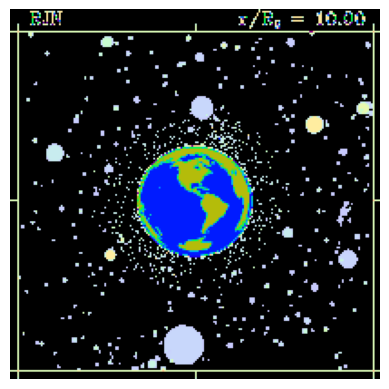

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/images/0.jpg')
plt.imshow(img)
plt.axis('off')

In [8]:
def label_data(title):
    title = title.lower()
    if 'galaxy' in title:
        return 0
    elif 'nebula' in title:
        return 1
    elif 'planet' in title or 'moon' in title:
        return 2
    else:
        return 3

df['label'] = df['title'].apply(label_data)

In [9]:
limit = 2000
df = df.iloc[:limit].copy()

In [10]:
import os
import requests
from tqdm import tqdm

os.makedirs('/content/images', exist_ok=True)

valid_indices = []

def download_image(url, path):
    try:
        r = requests.get(url, timeout=8)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return True
    except:
        return False
    return False

for i in tqdm(range(len(df))):
    url = df.iloc[i]['hdurl']
    path = f'/content/images/{i}.jpg'

    success = download_image(url, path)

    if success:
        valid_indices.append(i)

print("Downloaded:", len(valid_indices))

100%|██████████| 2000/2000 [08:43<00:00,  3.82it/s]

Downloaded: 1992


(np.float64(-0.5), np.float64(203.5), np.float64(203.5), np.float64(-0.5))

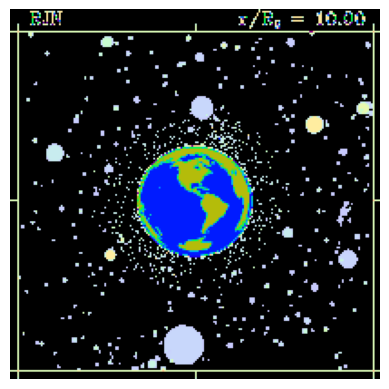

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/images/0.jpg')
plt.imshow(img)
plt.axis('off')

In [12]:
def label_data(title):
    title = title.lower()

    if 'galaxy' in title:
        return 0
    elif 'nebula' in title:
        return 1
    elif 'planet' in title or 'moon' in title:
        return 2
    else:
        return 3

df['label'] = df['title'].apply(label_data)

In [13]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

In [15]:
class APODDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = f"{self.img_dir}/{idx}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [17]:
train_dataset = APODDataset(train_df, '/content/images', transform)
val_dataset = APODDataset(val_df, '/content/images', transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 4)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 61.7MB/s]


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)